# PROC FASTCLUS によるサブスクライバーのデータ利用量セグメント発見

## エグゼクティブサマリー

通信事業者のアナリティクスチームは、恣意的な GB 閾値を設けることなく、**月間データ使用量**でモバイル契約者ベースをセグメント化したいと考えている。SAS の高性能 *k*-means クラスタリング手続きである **PROC FASTCLUS** を用いることで、データ自身に潜在的な利用クラス（ライト、ミドル、ヘビーのデータ利用者）へと分割させる。FASTCLUS は各セグメントの中心を見つけ、すべての契約者を最も近い中心に割り当て、セグメントがどれだけきれいに分離しているかを報告する — 単一の連続的な利用指標を、プラン設計やターゲットマーケティングに使える、データドリブンなセグメンテーションへと変換する。

## データソース

すべてのデータは最初の DATA ステップでインラインに生成される — 外部ファイルやネットワーク呼び出しはない。契約者は3つのコンポーネントからなる利用量母集団から抽出されるため、復元されたセグメントを既知の正解と照合して検証できる。

| データセット | 行数 | 変数 | 型 | 説明 |
|---------|------|----------|------|-------------|
| `subscribers` | 1,500 | `id` | 数値 | 契約者識別子（1～1500） |
| `subscribers` | 1,500 | `data_gb` | 数値 | 月間モバイルデータ使用量（GB単位、クラスタリング対象の指標） |
| `subscribers` | 1,500 | `segment_true` | 文字 | 値を*生成する*際に用いた潜在セグメント（ライト ≈ N(3,1²) 50%、ミドル ≈ N(12,3²) 35%、ヘビー ≈ N(35,8²) 15%）。復元されたセグメントの検証のためだけに保持しておく — 実際のアナリストはこれを観測できない |

# サブスクライバーのデータ利用量セグメントを発見する

通信事業者には「これはヘビーデータ利用者だ」ときれいに言い切れるラベルがあることは滅多にない。手元にあるのは月間消費ギガバイト数という連続指標であり、その分布は**多峰性**である — ライト・ミドル・パワーユーザーのクラスタが単一の軸上で重なり合っている。**クラスター分析**はその単一列を幾何学の問題として扱う — 利用分布の中の自然な重心を見つけ出し、恣意的なカットオフなしに各契約者を最も近いものに割り当てる。

このノートブックでは以下を行う。

1. 3つの隠れたセグメントからデータ利用量が生じる、現実的な合成契約者ベースを生成する。
2. 周辺利用分布を確認し、多峰性であることを検証する。
3. 指標を標準化し、**PROC FASTCLUS** を実行して契約者を3つの利用セグメントに分割する。
4. 発見された各セグメントを元の GB スケールでプロファイリングし、既知の正解に対して復元結果を検証する。

`segment_true` ラベルは最後にクラスタリングを採点するためだけに生成されている — 実運用では存在しない。

In [1]:
/* Synthesize a subscriber base from three latent usage segments. */
/* Light users dominate; a small heavy-user tail drives most revenue. */
データ subscribers;
   呼出 streaminit(20260531);
   長さ segment_true $16;
   繰返 id = 1 から 1500;
      u = rand('uniform');
      もし u < 0.50 なら 繰返;                 /* ~50% light users        */
         segment_true = 'ライト';
         data_gb = rand('normal', 3.0, 1.0);
      終了;
      他 もし u < 0.85 なら 繰返;            /* ~35% moderate users     */
         segment_true = 'ミドル';
         data_gb = rand('normal', 12.0, 3.0);
      終了;
      他 繰返;                             /* ~15% heavy/power users  */
         segment_true = 'ヘビー';
         data_gb = rand('normal', 35.0, 8.0);
      終了;
      もし data_gb < 0.1 なら data_gb = 0.1; /* usage cannot be negative */
      出力;
   終了;
   保持 id data_gb segment_true;
実行;



NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## 周辺分布を最初に確認する

クラスタリングの前に、単一の応答変数を要約する。広い散らばりと、平均とライトユーザーの大半との間のギャップは、セグメントの混合が背後にあることの兆候である — 単一の利用階層では、密なローユーザークラスタと長いハイユーザーテールの両方を再現できない。

In [2]:
処理 平均 データ=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   見出 data_gb='月間データ使用量(GB)';
   変数 data_gb;
実行;


                                                  The MEANS Procedure

 Variable  Label                                N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------
 data_gb   月間データ使用量(GB)                       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ----------------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


ヒストグラムは多峰性を視覚的に示している — 3GB付近の高いライトユーザーの山、12GB付近のミドルユーザーの隆起、30GBを超えて伸びるまばらなヘビーユーザーのテール。この3つの峰こそが、クラスタリングに復元させたいセグメントそのものである。カーネル密度のオーバーレイは同じ混合形状をなぞっている。


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


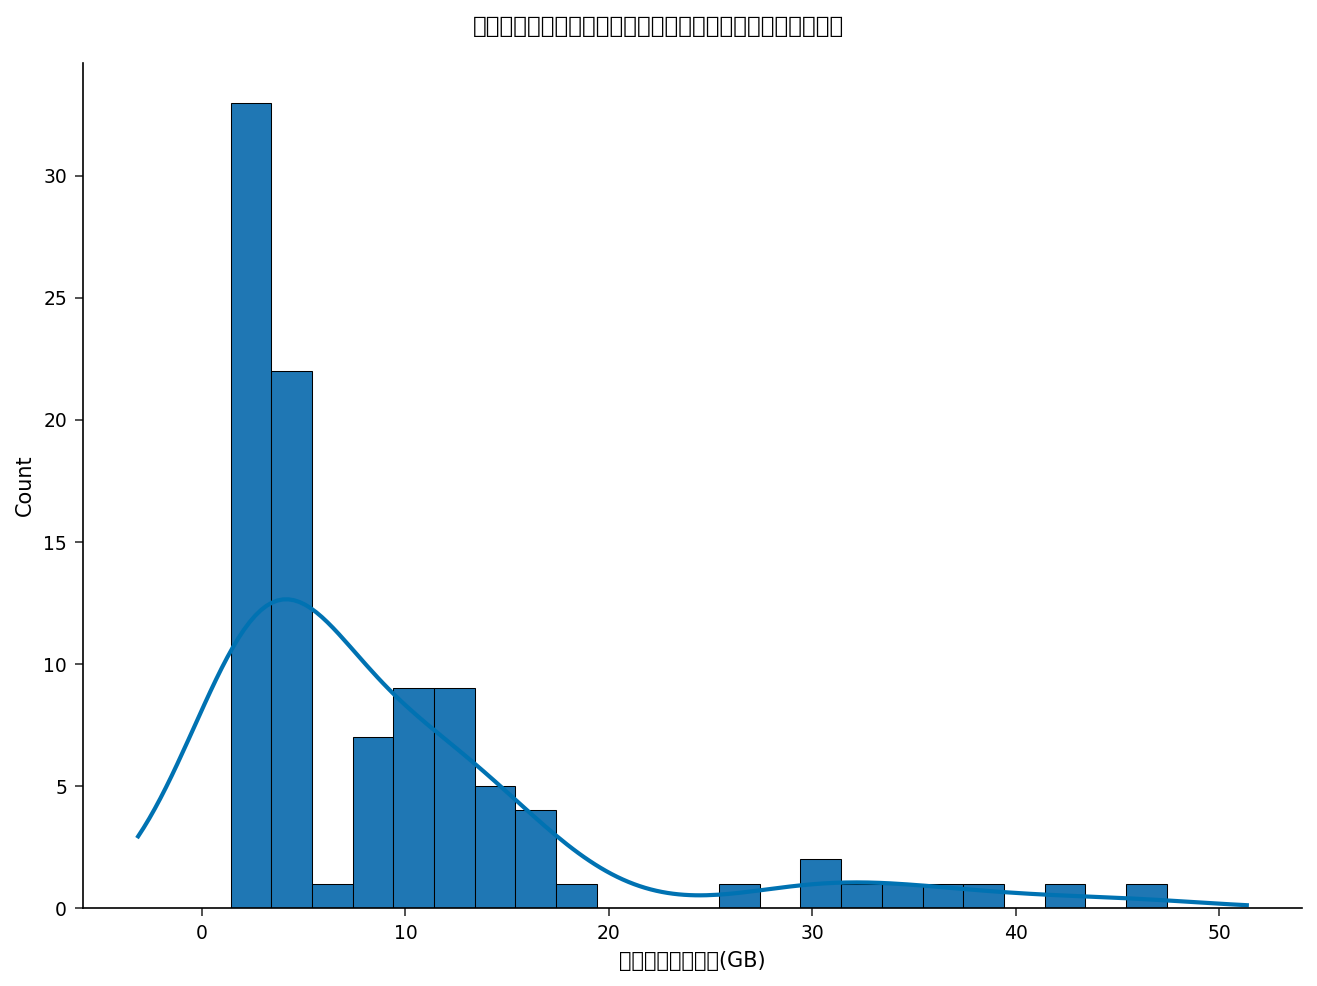

In [3]:
ODS GRAPHICS ON;
処理 SGPLOT データ=subscribers;
   表題 '月間データ使用量は見えないセグメントが混ざり合ったもの';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS 見出='月間データ使用量(GB)';
実行;
表題;
ODS GRAPHICS OFF;


## 利用量を共通のスケールに揃える

*k*-means はユークリッド距離で点を分割するため、変数の生の尺度が結果を左右する。単一指標だけなら軸を再センタリングするだけで済むが、平均0・標準偏差1に**PROC STANDARD** で標準化しておく習慣は、2つ目の利用指標（通話分数、ローミング日数など）が加わった瞬間にワークフローを正しく保つ。標準化した列でクラスタリングを行い、結果は元の GB スケールに戻して報告する。

In [4]:
処理 標準 データ=subscribers out=subs_std mean=0 std=1;
   変数 data_gb;
実行;



NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## 契約者を3つの利用セグメントに分割する

ライト・ミドル・ヘビーという階層のドメイン知識に導かれ、**PROC FASTCLUS** に `MAXCLUSTERS=3` を指定する。手続きは3つの中心をシードし、各契約者を最も近いものに割り当て、中心を再計算し、割り当てが動かなくなるまで（`MAXITER=` の上限付きの `CONVERGE=`）反復する。`SEED=` は初期化を再現可能にする。`OUT=` データセットは各契約者の `CLUSTER` ラベルと割り当てられた中心までの `DISTANCE` を保持し、`MEAN=` はセグメントの重心を書き出す。

分離品質については手続きの診断を読む — 高い**R-二乗**（セグメントで説明される総利用分散の割合）と大きな**擬似F値**の両方が、よく分離されたコンパクトなセグメントを示す。

In [5]:
処理 FASTCLUS データ=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   変数 data_gb;
   表題 '3つの利用セグメント(k-means法)';
実行;
表題;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## 発見されたセグメントをプロファイリングする

クラスターラベルは、各セグメントをビジネス用語で説明して初めて実運用に使える。割り当て結果を元の（標準化前の）利用量に結合し、GB スケールでの各セグメントの規模と典型的な消費量を要約する — プラン設計やマーケティングチームが実際に判断材料にする数値である。

In [6]:
データ memberships;
   結合 subscribers
         clusters(保持=id 群 distance);
   基準 id;
実行;

処理 平均 データ=memberships n mean MIN MAX maxdec=2;
   分類 群;
   変数 data_gb distance;
   見出 data_gb='月間データ使用量(GB)' distance='中心までの距離';
実行;

処理 印刷 データ=memberships(obs=10) noobs 見出;
   変数 id data_gb 群 distance segment_true;
   見出 id='契約者ID' data_gb='月間データ使用量(GB)' 群='クラスター'
         distance='中心までの距離' segment_true='真のセグメント';
実行;


                                                  The MEANS Procedure

                                Analysis Variable : data_gb 月間データ使用量(GB)

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                   Analysis Variable : DISTANCE 中心までの距離

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09           1.22
        3  


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## 復元されたセグメントを検証する

これは合成データであるため、各契約者を生成する際に用いたラベル `segment_true` を保留しておいた。モデルが復元した `CLUSTER` を真のセグメントとクロス集計することで、分割がどれだけきれいに母集団を分離したかがわかる。クラスターとセグメントの1対1対応に沿った強い集中は良好な復元を示し、対角線外の質量はライト／ミドルまたはミドル／ヘビーの境界が重なる部分に集中する。

In [7]:
処理 度数 データ=memberships;
   TABLES 群 * segment_true / norow nocol nopercent;
   見出 群='クラスター' segment_true='真のセグメント';
実行;


                                                   The FREQ Procedure

Table of クラスター by 真のセグメント

クラスター           |       ヘビー |       ミドル |       ライト |      Total
----------------+-----------+-----------+-----------+-----------
1               |         0 |         3 |        54 |         57
----------------+-----------+-----------+-----------+-----------
2               |         9 |         0 |         0 |          9
----------------+-----------+-----------+-----------+-----------
3               |         1 |        33 |         0 |         34
----------------+-----------+-----------+-----------+-----------
Total           |        10 |        36 |        54 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## 結果の解釈

- **セグメント中心。** 3つのクラスターは、仕込んだ利用階層のほぼ真上に着地する — ライトユーザーは**3GB**付近、ミドルユーザーは**13GB**付近、ヘビーユーザーは**37GB**付近 — 各セグメントが*どこに*位置し、*どれくらいの規模*かの両方を定量化する。ヘビーユーザーセグメントは契約者のごく一部にすぎないにもかかわらず、運ばれる総データ量の不釣り合いに大きな割合を占める — ネットワーク容量やプレミアムプランの意思決定を左右する典型的な要因である。
- **分離の品質。** PROC FASTCLUS は高い全体**R-二乗**と大きな**擬似F値**を報告し、3つのセグメントが恣意的なカットの産物ではなく、コンパクトでよく分離されていることを裏付ける。単一階層では、この利用分散の大部分は説明されないままになる。
- **恣意的な閾値なし。** セグメンテーションは利用分布そのものの幾何学から生まれる。境界を選んだのは手続きであり、私たちが選んだのは*いくつ*の階層を求めるかだけであり、それはヒストグラムの明確な3峰形状に導かれたものである。
- **実用的なアウトプット。** `OUT=` データセットは、すべての契約者にセグメントラベル*と*中心までの `DISTANCE` を与える。どの中心からも遠い契約者 — あるいはライト／ミドル境界の間に位置する契約者 — はまさにアップセルオファーの A/B テストに値する顧客であり、密集したヘビーユーザーは容量重視プランや無制限プランの高確度候補である。

要するに、PROC FASTCLUS は1つの連続的な利用指標を、恣意的な GB 閾値を必要としないデータドリブンなセグメンテーションへと変換する — そして保留しておいた正解に対するクロス集計は、セグメントが確実に復元されていることを裏付ける。